# Notebook 1 - EDA (Exploratory Data Analysis)

Importando bibliotecas básicas:

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Configurando os gráficos:

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Importando o dataset:

In [4]:
df = pd.read_csv('../data/raw/cs-training.csv')
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Renomeando as colunas:

In [5]:
df = df.drop(columns = ["Unnamed: 0"])

novas_colunas = {
    'SeriousDlqin2yrs': 'inadimplente',
    'RevolvingUtilizationOfUnsecuredLines': 'uso_credito_rotativo',
    'age': 'idade',
    'NumberOfTime30-59DaysPastDueNotWorse': 'atrasos_30_59_dias',
    'DebtRatio': 'razao_divida_renda',
    'MonthlyIncome': 'renda_mensal',
    'NumberOfOpenCreditLinesAndLoans': 'linhas_credito_abertas',
    'NumberOfTimes90DaysLate': 'atrasos_90_dias_ou_mais',
    'NumberRealEstateLoansOrLines': 'emprestimos_imobiliarios',
    'NumberOfTime60-89DaysPastDueNotWorse': 'atrasos_60_89_dias',
    'NumberOfDependents': 'num_dependentes'
}

df = df.rename(columns=novas_colunas)

In [6]:
df.head()

,inadimplente,uso_credito_rotativo,idade,atrasos_30_59_dias,razao_divida_renda,renda_mensal,linhas_credito_abertas,atrasos_90_dias_ou_mais,emprestimos_imobiliarios,atrasos_60_89_dias,num_dependentes
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Visualizando formato da tabela:

In [7]:
df.shape

(150000, 11)

Obtendo informações sobre cada coluna

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   inadimplente              150000 non-null  int64  
 1   uso_credito_rotativo      150000 non-null  float64
 2   idade                     150000 non-null  int64  
 3   atrasos_30_59_dias        150000 non-null  int64  
 4   razao_divida_renda        150000 non-null  float64
 5   renda_mensal              120269 non-null  float64
 6   linhas_credito_abertas    150000 non-null  int64  
 7   atrasos_90_dias_ou_mais   150000 non-null  int64  
 8   emprestimos_imobiliarios  150000 non-null  int64  
 9   atrasos_60_89_dias        150000 non-null  int64  
 10  num_dependentes           146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


Verificando medidas estatísticas relevantes da tabela:

In [9]:
df.describe()

,inadimplente,uso_credito_rotativo,idade,atrasos_30_59_dias,razao_divida_renda,renda_mensal,linhas_credito_abertas,atrasos_90_dias_ou_mais,emprestimos_imobiliarios,atrasos_60_89_dias,num_dependentes
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Verificando linhas repetidas e colunas com missing values:

In [17]:
print(df.duplicated().sum())

609


In [18]:
print(df.isnull().sum())

inadimplente                    0
uso_credito_rotativo            0
idade                           0
atrasos_30_59_dias              0
razao_divida_renda              0
renda_mensal                29731
linhas_credito_abertas          0
atrasos_90_dias_ou_mais         0
emprestimos_imobiliarios        0
atrasos_60_89_dias              0
num_dependentes              3924
dtype: int64


Removendo linhas duplicadas:

In [19]:
df = df.drop_duplicates()

Verificando a média, mediana e moda das colunas com missing values:

In [23]:
colunas_missing = ['renda_mensal', 'num_dependentes']
for col in colunas_missing:
    print(f"Missing: {df[col].isnull().sum()}")
    print(f"Média: {df[col].mean():.2f}")
    print(f"Mediana: {df[col].median():.2f}")
    print(f"Moda: {df[col].mode()[0]:.2f}\n")

Missing: 29221
Média: 6675.10
Mediana: 5400.00
Moda: 5000.00

Missing: 3828
Média: 0.76
Mediana: 0.00
Moda: 0.00



Com isso, vou trocar os missing values da coluna de renda pela mediana e da coluna de dependentes pela moda:

In [24]:
df['renda_mensal'] = df['renda_mensal'].fillna(df['renda_mensal'].median())
df['num_dependentes'] = df['num_dependentes'].fillna(df['num_dependentes'].mode()[0])

Verificando se tudo ocorreu corretamente:

In [25]:
print(df.duplicated().sum())
print(df.isnull().sum())

158
inadimplente                0
uso_credito_rotativo        0
idade                       0
atrasos_30_59_dias          0
razao_divida_renda          0
renda_mensal                0
linhas_credito_abertas      0
atrasos_90_dias_ou_mais     0
emprestimos_imobiliarios    0
atrasos_60_89_dias          0
num_dependentes             0
dtype: int64


Analisando a variável target (inadimplente):

In [26]:
print(df['inadimplente'].value_counts())

inadimplente
0    139382
1     10009
Name: count, dtype: int64


Pode-se observar que há uma desbalanceio gigantesco de dados. Isso é importante para o futuro e será resolvido com o uso de SMOTE em outro notebook

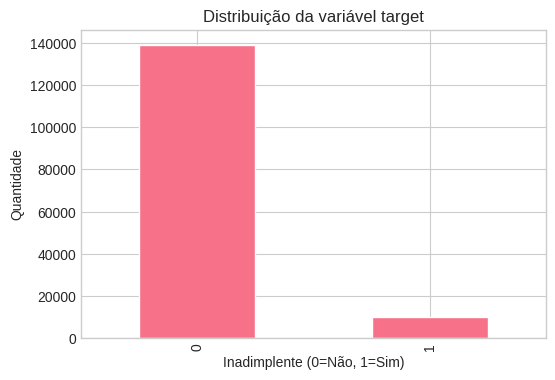

In [27]:
plt.figure(figsize=(6,4))
df['inadimplente'].value_counts().plot(kind='bar')
plt.title("Distribuição da variável target")
plt.xlabel("Inadimplente (0=Não, 1=Sim)")
plt.ylabel("Quantidade")
plt.show()

Análise de distribuição:

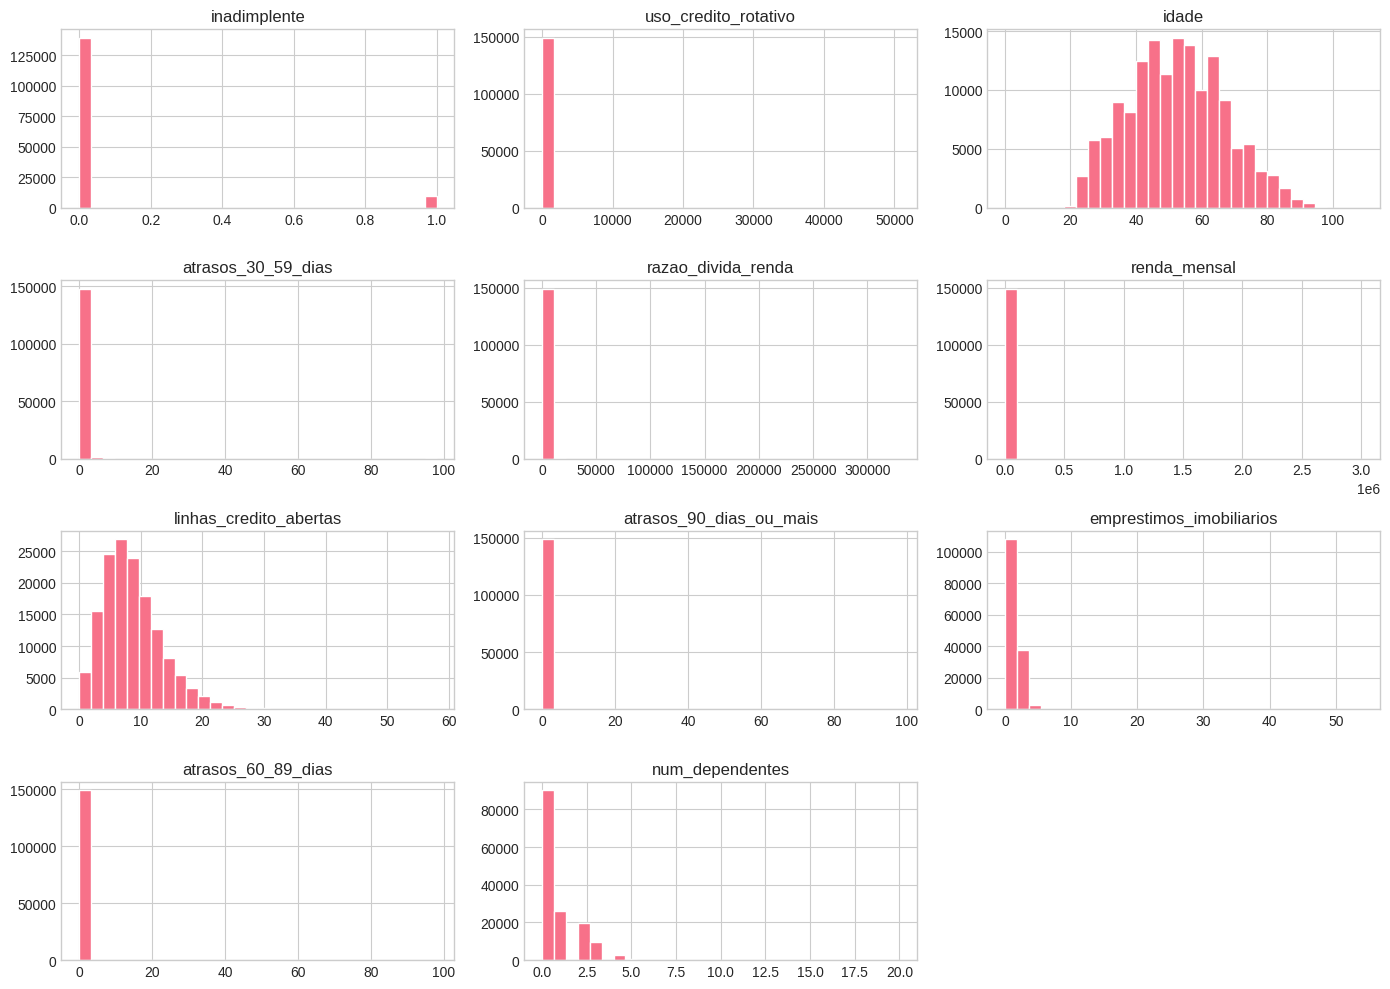

In [28]:
df.hist(figsize=(14,10), bins = 30)
plt.tight_layout()
plt.show()

Analisando e verificando possíveis outliers:

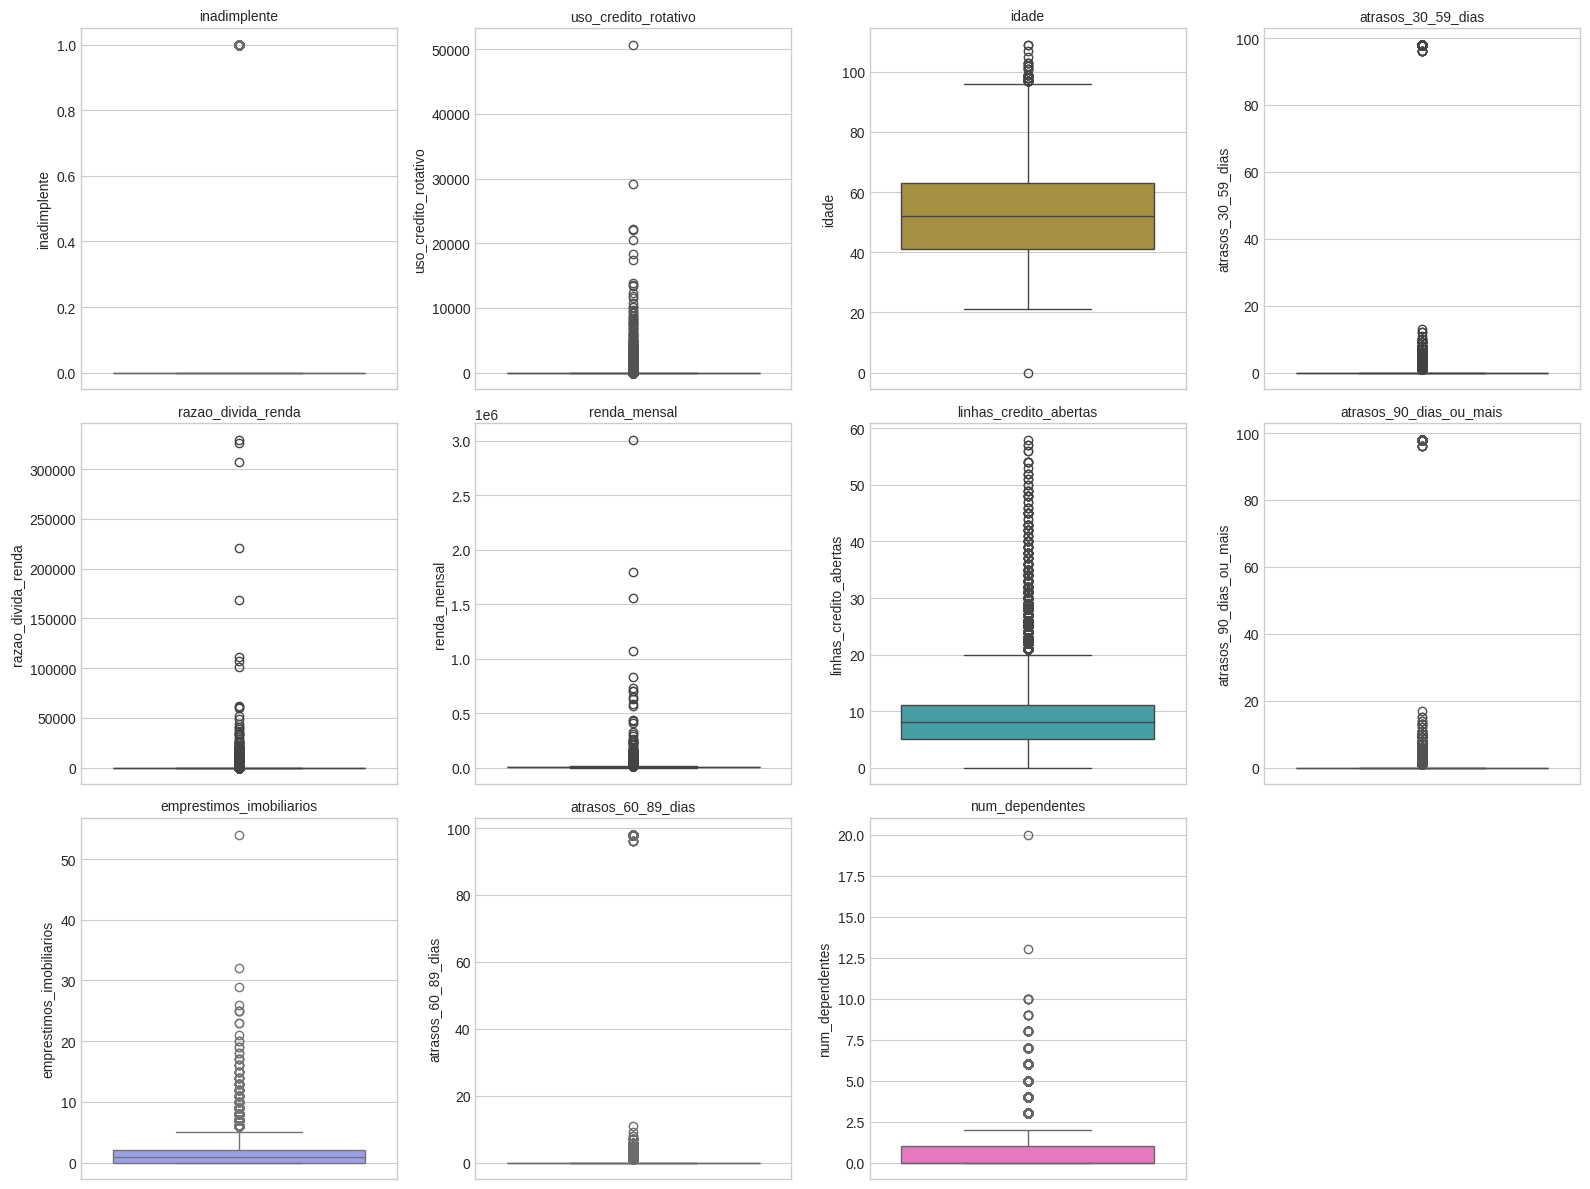

In [35]:
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
n_colunas = len(colunas_numericas)
n_linhas = (n_colunas // 4) + 1
fig, axes = plt.subplots(n_linhas, 4, figsize=(16, n_linhas * 4))
axes = axes.flatten()
cores = sns.color_palette("husl", n_colunas)
for i, col in enumerate(colunas_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color=cores[i])
    axes[i].set_title(col, fontsize=10)
for j in range(n_colunas, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Plotando a matriz de correlação:

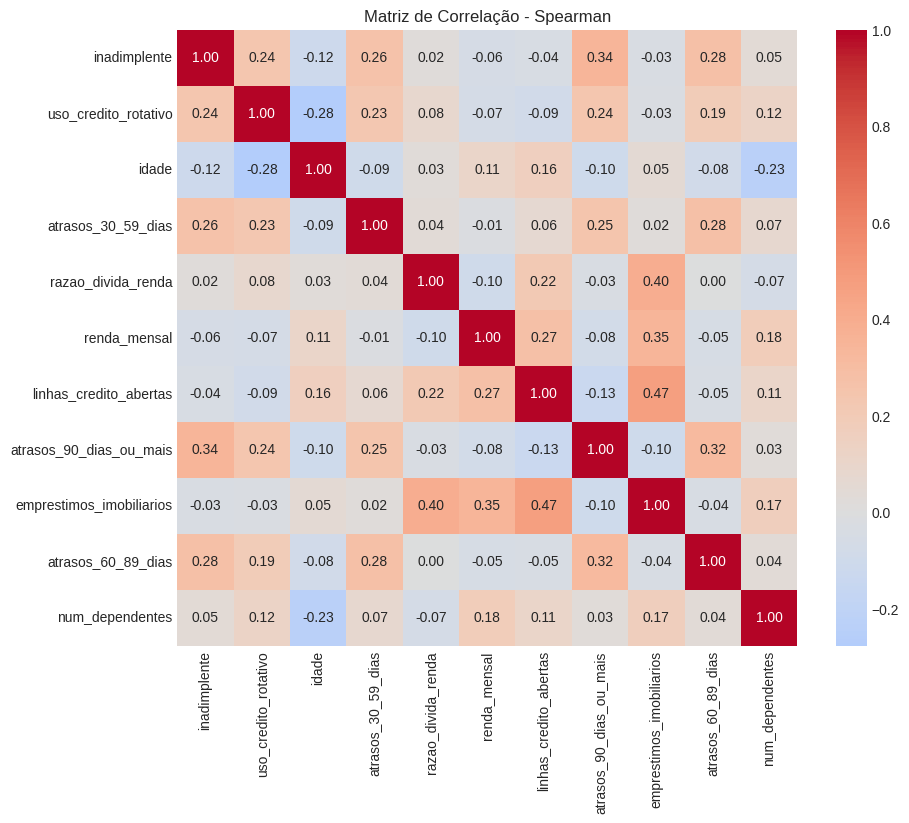

In [36]:
corr = df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação - Spearman')
plt.show()

In [37]:
 print(corr['inadimplente'].sort_values(ascending=False))

inadimplente                1.000000
atrasos_90_dias_ou_mais     0.342698
atrasos_60_89_dias          0.277070
atrasos_30_59_dias          0.257104
uso_credito_rotativo        0.240961
num_dependentes             0.046528
razao_divida_renda          0.019660
emprestimos_imobiliarios   -0.034897
linhas_credito_abertas     -0.039539
renda_mensal               -0.062020
idade                      -0.117261
Name: inadimplente, dtype: float64


## Conclusões finais:

* As variáveis mais importantes são as de atrasos e uso_credito_rotativo;
* Existem outliers a serem tratados;

## Exportando o dataset

In [38]:
df.to_parquet('../data/processed/dados_eda.parquet')

## Resumo da Análise Exploratória (EDA)

  ### Dados carregados:
  - **Shape original**: 150.000 linhas x 11 colunas
  - **Target**: `inadimplente` (0 = adimplente, 1 = inadimplente)

  ### Qualidade dos dados:
  - **Duplicatas**: 609 linhas removidas
  - **Missing values encontrados**:
    - `renda_mensal`: 29.731 (19.8%) → imputado com mediana (5400)
    - `num_dependentes`: 3.924 (2.6%) → imputado com moda (0)

  ### Desbalanceamento do target:
  - Classe 0 (adimplente): ~93%
  - Classe 1 (inadimplente): ~7%
  - **Estratégia futura**: usar SMOTE ou class_weight no treinamento

  ### Features mais correlacionadas com inadimplência:
  1. `atrasos_90_dias_ou_mais`: 0.34
  2. `atrasos_60_89_dias`: 0.28
  3. `atrasos_30_59_dias`: 0.26
  4. `uso_credito_rotativo`: 0.24
  5. `idade`: -0.12 (negativa - jovens têm mais risco)

  ### Outliers identificados:
  - `uso_credito_rotativo`: valores > 1 (deveria ser proporção)
  - `razao_divida_renda`: valores extremos (max 329.664)
  - `idade`: valor 0 (impossível)
  - `atrasos_*`: valor 98 (código especial)

  ### Próximos passos:
  - Tratar outliers no notebook 02_feature_engineering
  - Criar features derivadas
  - Preparar dados para modelagem